## Lab Report - DS424
- Beniamine Nahid
- 211-35-3155

### Experiment 1 : Digit Classification

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.utils import resample

In [2]:
# I. Load the dataset
data = pd.read_csv("digit.csv")

In [3]:
# II. Explore the dataset
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:

print("Dataset shape:", data.shape)


Dataset shape: (42000, 785)


In [6]:
data.isnull().sum()

label       0
pixel0      0
pixel1      0
pixel2      0
pixel3      0
           ..
pixel779    0
pixel780    0
pixel781    0
pixel782    0
pixel783    0
Length: 785, dtype: int64

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


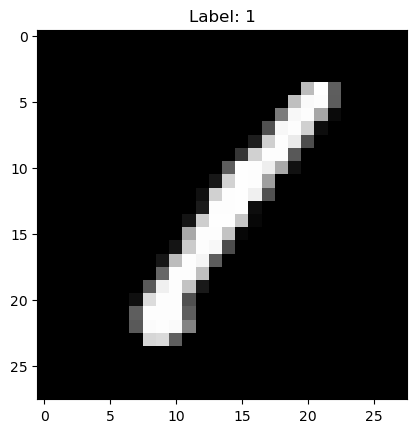

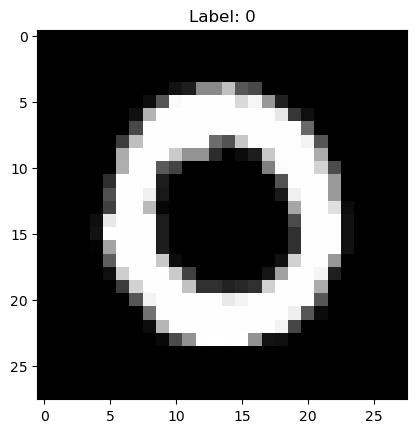

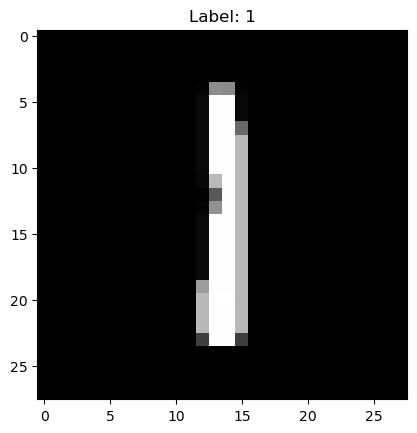

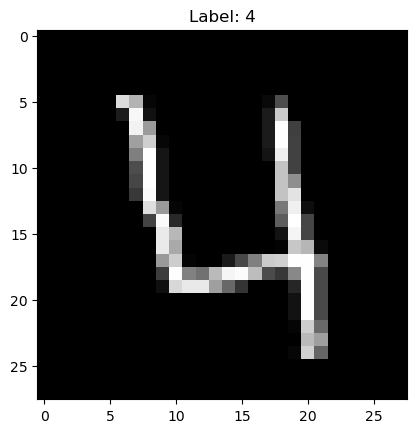

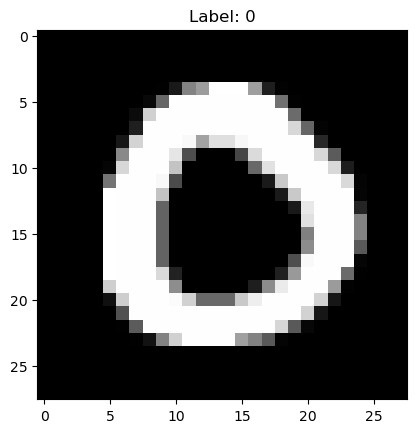

In [8]:
# III. Visualize some samples
for i in range(5):
    img = data.iloc[i, 1:].values.reshape(28, 28)
    plt.imshow(img, cmap="gray")
    plt.title(f"Label: {data.iloc[i, 0]}")
    plt.show()

In [9]:
# IV. Preprocess the data
X = data.iloc[:, 1:].values
y = data.iloc[:, 0].values
X = X / 255.0  # Normalize pixel values

In [10]:

# Reduce dataset size for faster execution
X, y = resample(X, y, n_samples=10000, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# V. Train models
models = {
    "Logistic Regression": LogisticRegression(max_iter=100),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier()
}

In [12]:
# VI. Hyperparameter tuning
param_grids = {
    "Logistic Regression": {"C": [0.1, 1, 10]},
    "SVM": {"C": [0.1, 1, 10], "kernel": ["linear", "rbf"]},
    "Decision Tree": {"max_depth": [5, 10, 20]}
}

In [13]:

best_models = {}
for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=3, scoring="accuracy")
    grid.fit(X_train, y_train)
    best_models[name] = grid.best_estimator_

/Applications/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Applications/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-

In [14]:
# VII. Evaluate on training data
for name, model in best_models.items():
    print(f"\nModel: {name}")
    y_pred_train = model.predict(X_train)
    print("Training Classification Report:\n", classification_report(y_train, y_pred_train))


Model: Logistic Regression
Training Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       736
           1       0.96      0.98      0.97       871
           2       0.93      0.92      0.93       747
           3       0.94      0.93      0.93       841
           4       0.95      0.96      0.95       762
           5       0.92      0.91      0.91       728
           6       0.96      0.97      0.96       819
           7       0.95      0.95      0.95       885
           8       0.91      0.91      0.91       797
           9       0.93      0.93      0.93       814

    accuracy                           0.94      8000
   macro avg       0.94      0.94      0.94      8000
weighted avg       0.94      0.94      0.94      8000


Model: SVM
Training Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       736
           1       1.00   

In [15]:
# VIII. Evaluate on test data with bootstrapping
for name, model in best_models.items():
    print(f"\nModel: {name}")
    scores = cross_val_score(model, X_test, y_test, cv=5, scoring="accuracy")
    print(f"Accuracy: {np.mean(scores):.2f} ± {np.std(scores):.2f}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, model.predict(X_test)))



Model: Logistic Regression
Accuracy: 0.90 ± 0.01
Confusion Matrix:
 [[210   0   1   1   0   1   5   1   2   0]
 [  0 208   0   0   0   1   0   1   1   1]
 [  0   3 157   3   6   1   5   0   1   0]
 [  0   0   4 179   0   2   0   0   4   0]
 [  0   2   0   0 193   0   3   0   1  10]
 [  3   0   0   9   2 159   3   2   3   1]
 [  1   0   2   1   1   3 193   0   0   0]
 [  1   2   0   0   0   1   0 224   1   7]
 [  0   7   2   8   0   4   1   1 150   3]
 [  3   0   1   2   5   0   1   7   1 178]]

Model: SVM
Accuracy: 0.95 ± 0.01
Confusion Matrix:
 [[217   0   1   0   0   0   2   0   1   0]
 [  0 211   0   0   0   0   0   0   0   1]
 [  0   1 171   1   0   2   1   0   0   0]
 [  0   0   3 184   0   1   0   0   1   0]
 [  0   1   1   0 203   0   1   0   0   3]
 [  0   0   0   3   0 177   0   1   0   1]
 [  0   0   0   0   0   3 198   0   0   0]
 [  1   0   0   0   0   0   0 235   0   0]
 [  0   1   1   1   1   0   1   0 171   0]
 [  1   0   1   0   3   1   0   4   2 186]]

Model: Decision

In [16]:
# IX. Evaluate test data using bootstrapping
from sklearn.utils import resample
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

bootstrap_results = {}

for name, model in best_models.items():
    accuracies, precisions, recalls, f1_scores = [], [], [], []
    
    for i in range(100):  # Bootstrapping iterations
        X_resample, y_resample = resample(X_test, y_test, random_state=i)
        y_pred = model.predict(X_resample)
        
        accuracies.append(accuracy_score(y_resample, y_pred))
        precisions.append(precision_score(y_resample, y_pred, average="weighted"))
        recalls.append(recall_score(y_resample, y_pred, average="weighted"))
        f1_scores.append(f1_score(y_resample, y_pred, average="weighted"))
    
    bootstrap_results[name] = {
        "Accuracy": (np.mean(accuracies), np.std(accuracies)),
        "Precision": (np.mean(precisions), np.std(precisions)),
        "Recall": (np.mean(recalls), np.std(recalls)),
        "F1 Score": (np.mean(f1_scores), np.std(f1_scores)),
    }

In [17]:
# Print bootstrapping results
for name, metrics in bootstrap_results.items():
    print(f"\n{name} Bootstrapping Results:")
    for metric, values in metrics.items():
        print(f"{metric}: {values[0]:.2f} ± {1.96 * values[1]:.2f}")


Logistic Regression Bootstrapping Results:
Accuracy: 0.93 ± 0.01
Precision: 0.93 ± 0.01
Recall: 0.93 ± 0.01
F1 Score: 0.93 ± 0.01

SVM Bootstrapping Results:
Accuracy: 0.98 ± 0.01
Precision: 0.98 ± 0.01
Recall: 0.98 ± 0.01
F1 Score: 0.98 ± 0.01

Decision Tree Bootstrapping Results:
Accuracy: 0.84 ± 0.02
Precision: 0.84 ± 0.02
Recall: 0.84 ± 0.02
F1 Score: 0.84 ± 0.02


In [18]:
# X. Compare models and select the best one
print("\nModel Comparison (Test Data):")
for name, metrics in bootstrap_results.items():
    print(f"{name}: Accuracy={metrics['Accuracy'][0]:.2f}, F1 Score={metrics['F1 Score'][0]:.2f}")



Model Comparison (Test Data):
Logistic Regression: Accuracy=0.93, F1 Score=0.93
SVM: Accuracy=0.98, F1 Score=0.98
Decision Tree: Accuracy=0.84, F1 Score=0.84


### Experiment 2 : Predicting House Prices

In [19]:
# Import necessary libraries
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

In [20]:
# I. Load the dataset
data = pd.read_csv("house.csv")  

In [21]:
# II. Explore the dataset
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [22]:
data.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [23]:
print("Dataset shape:", data.shape)
print(data.describe())

Dataset shape: (1460, 81)
                Id   MSSubClass  LotFrontage        LotArea  OverallQual  \
count  1460.000000  1460.000000  1201.000000    1460.000000  1460.000000   
mean    730.500000    56.897260    70.049958   10516.828082     6.099315   
std     421.610009    42.300571    24.284752    9981.264932     1.382997   
min       1.000000    20.000000    21.000000    1300.000000     1.000000   
25%     365.750000    20.000000    59.000000    7553.500000     5.000000   
50%     730.500000    50.000000    69.000000    9478.500000     6.000000   
75%    1095.250000    70.000000    80.000000   11601.500000     7.000000   
max    1460.000000   190.000000   313.000000  215245.000000    10.000000   

       OverallCond    YearBuilt  YearRemodAdd   MasVnrArea   BsmtFinSF1  ...  \
count  1460.000000  1460.000000   1460.000000  1452.000000  1460.000000  ...   
mean      5.575342  1971.267808   1984.865753   103.685262   443.639726  ...   
std       1.112799    30.202904     20.645407   1

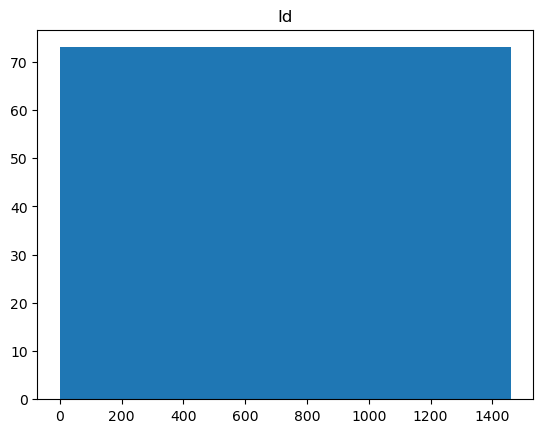

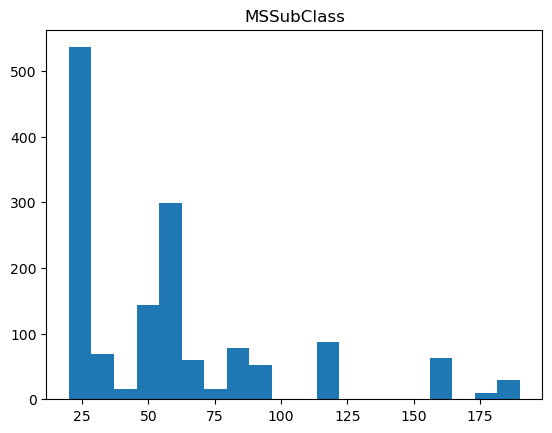

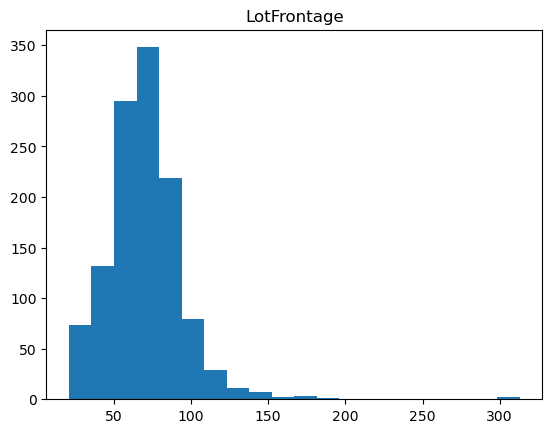

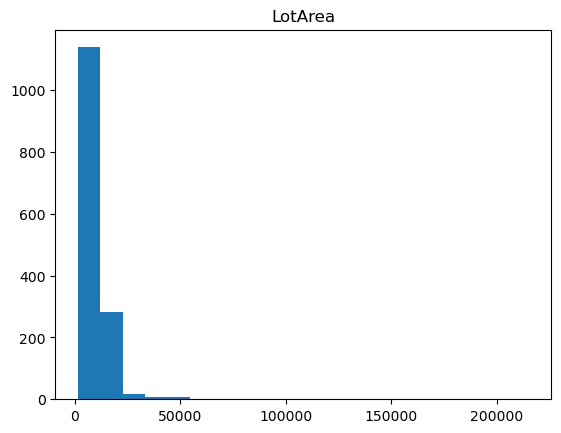

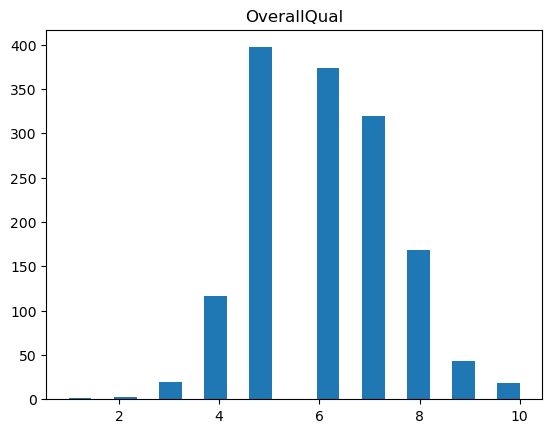

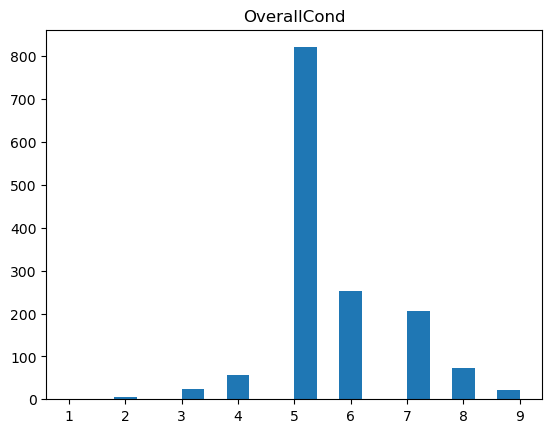

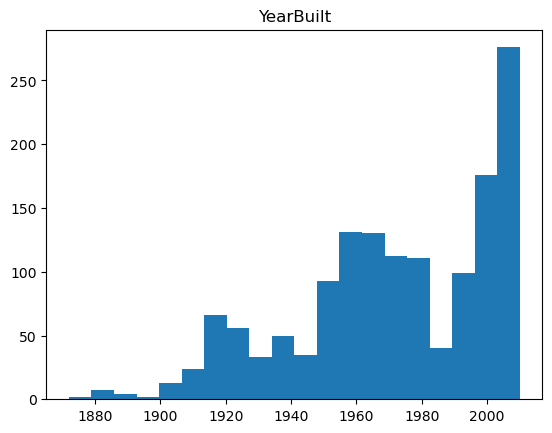

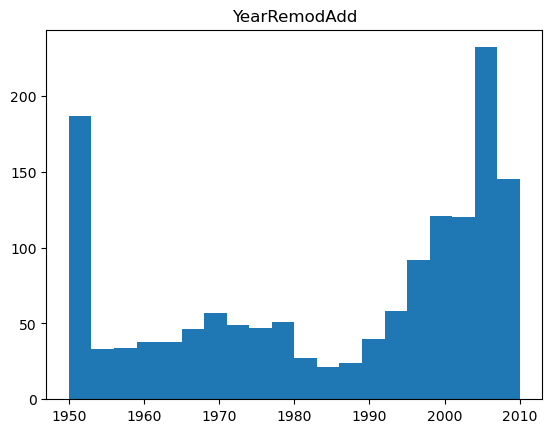

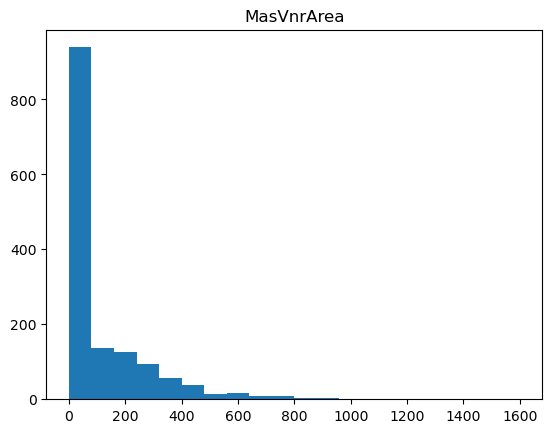

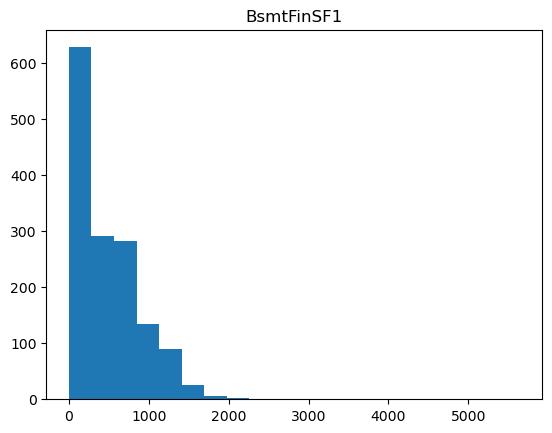

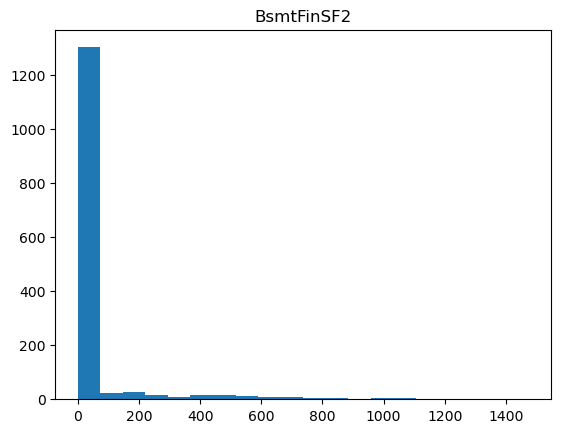

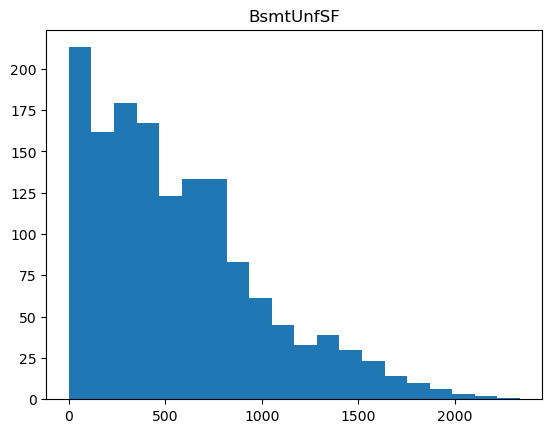

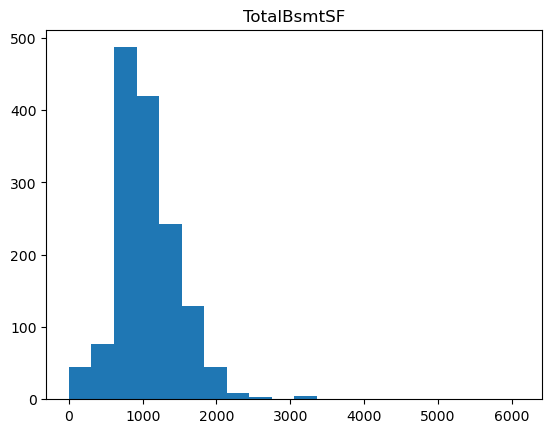

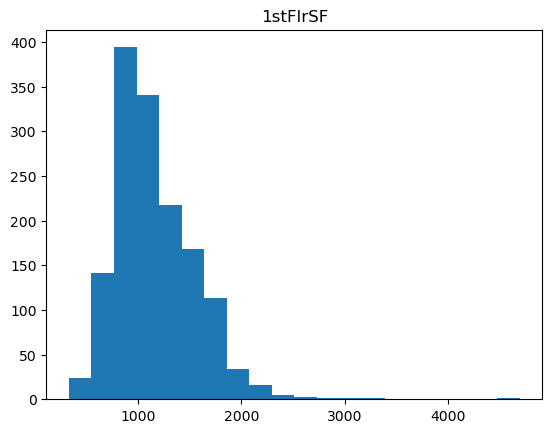

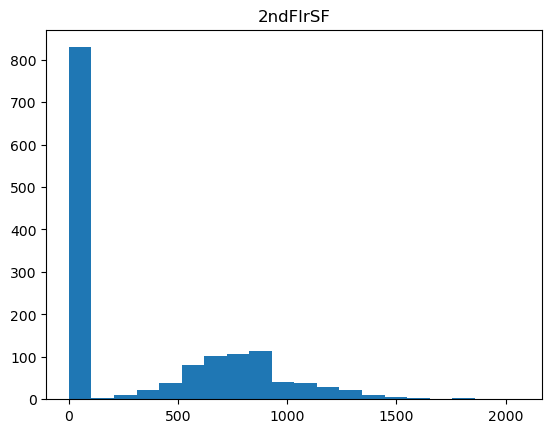

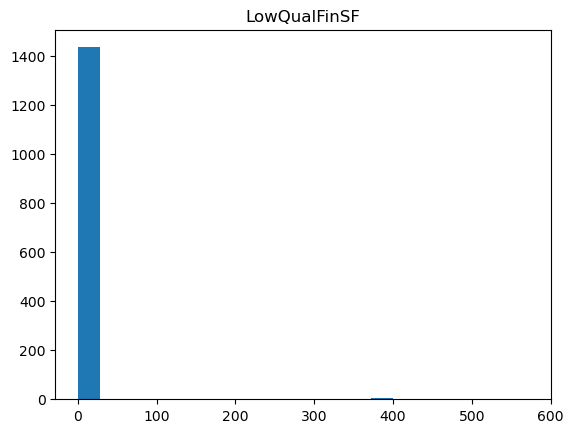

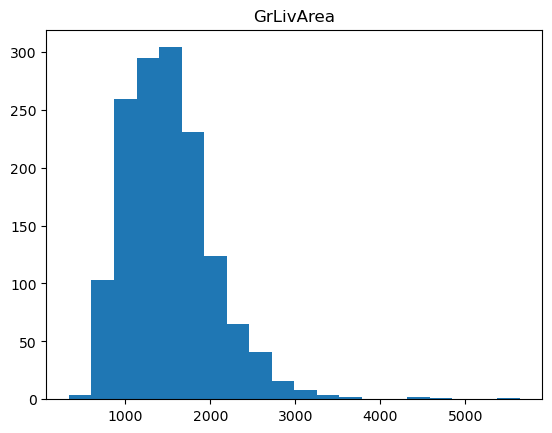

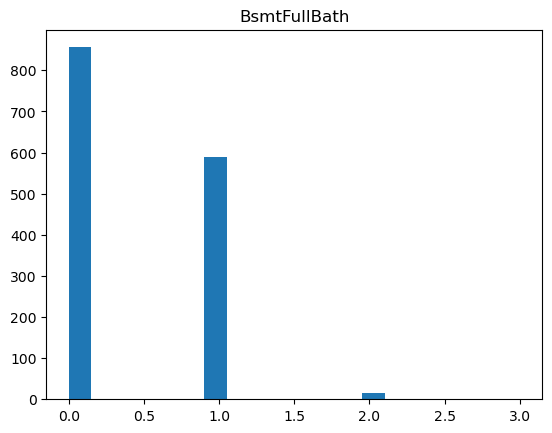

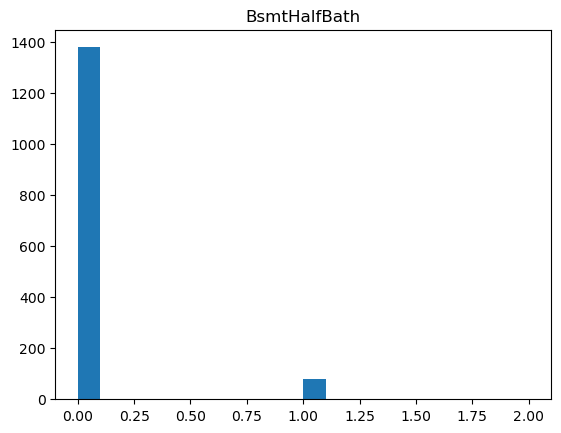

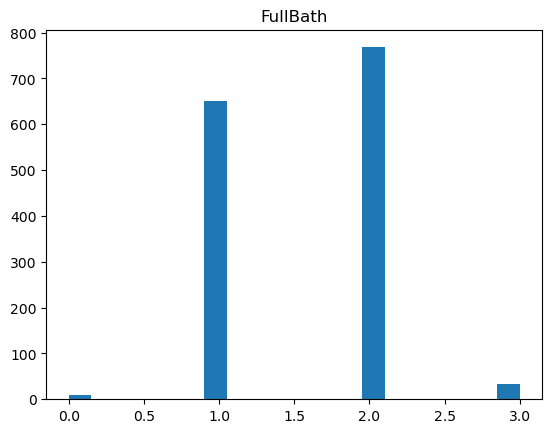

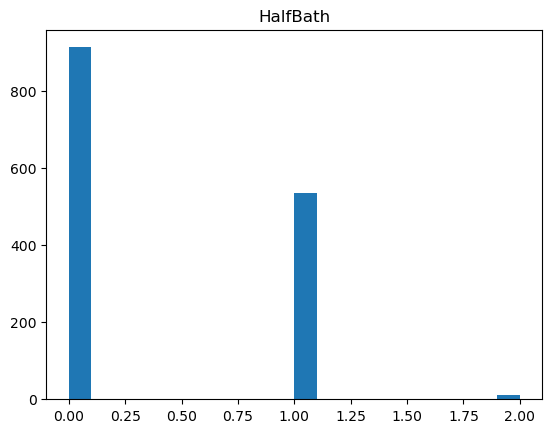

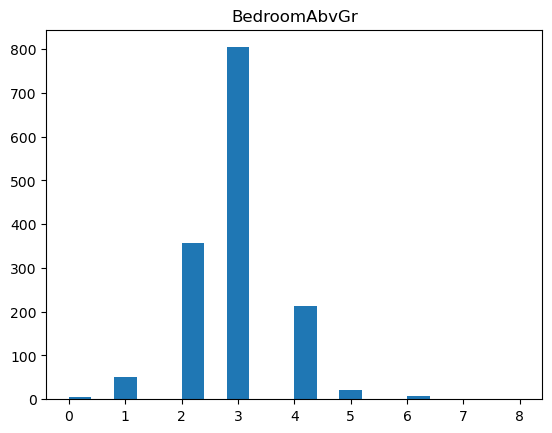

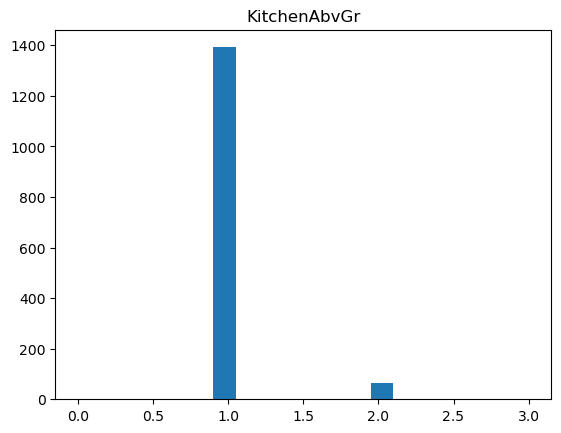

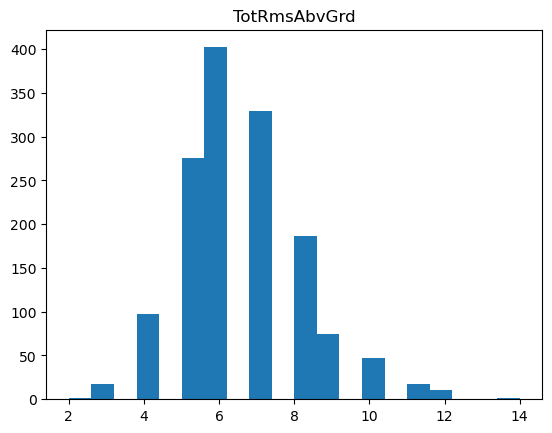

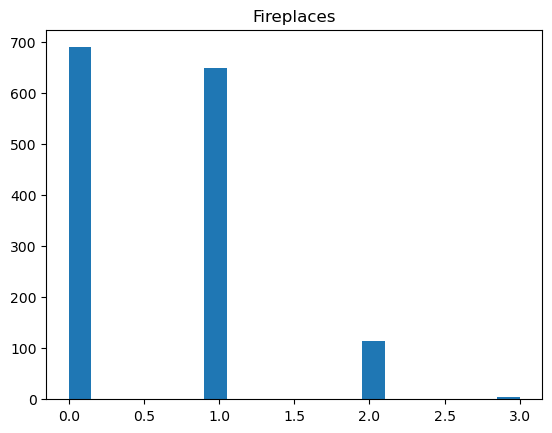

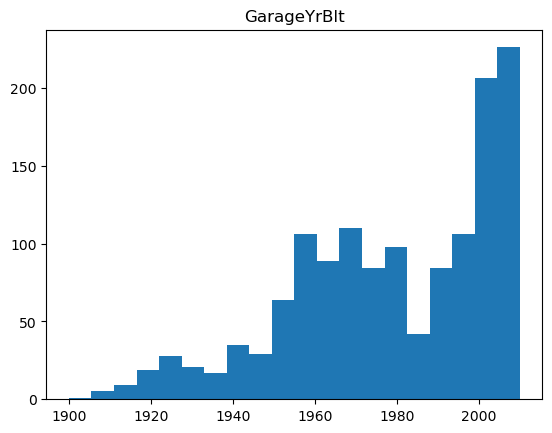

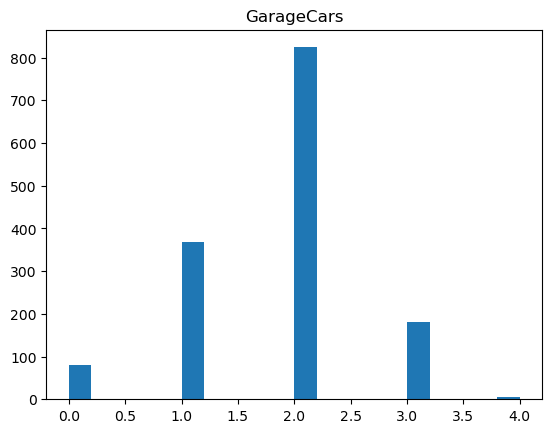

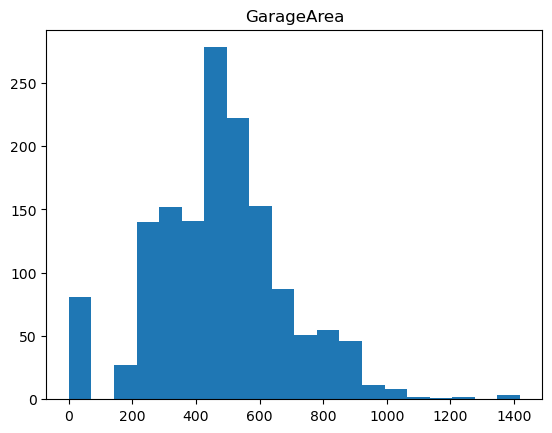

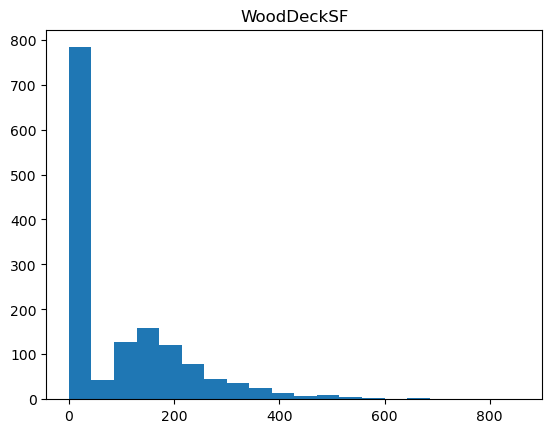

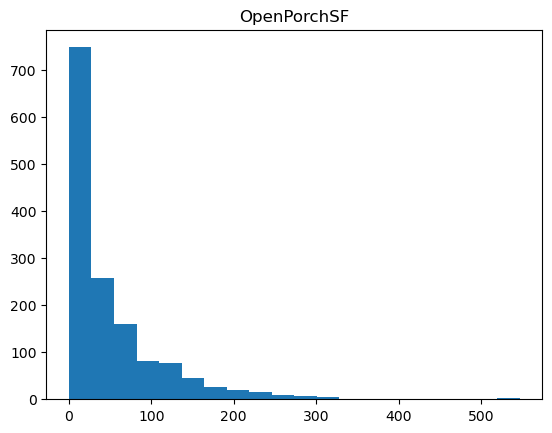

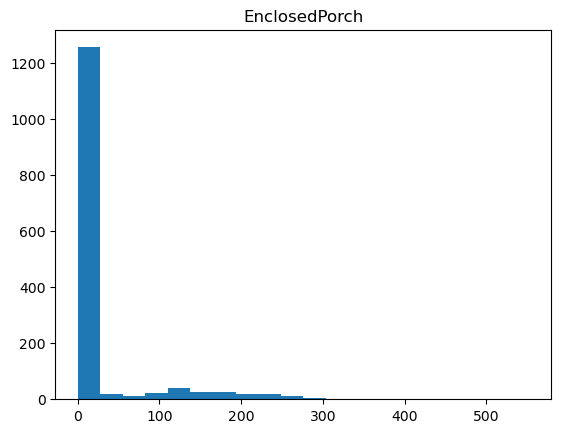

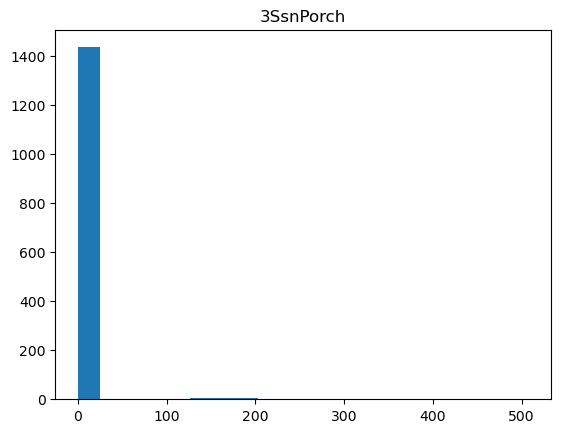

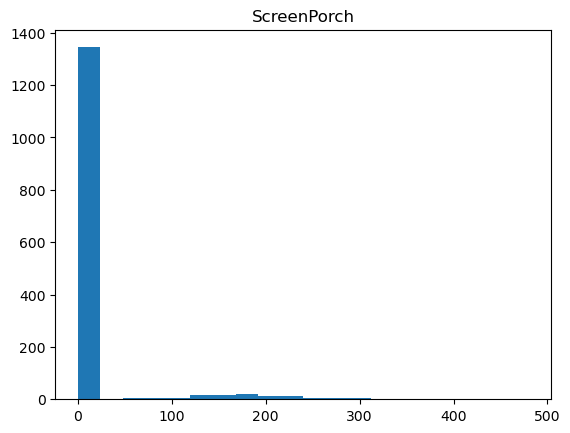

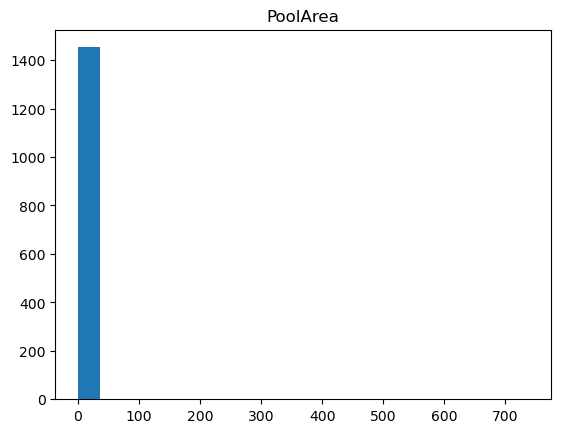

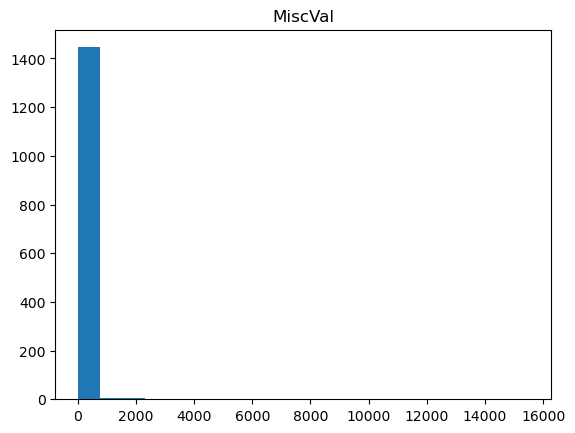

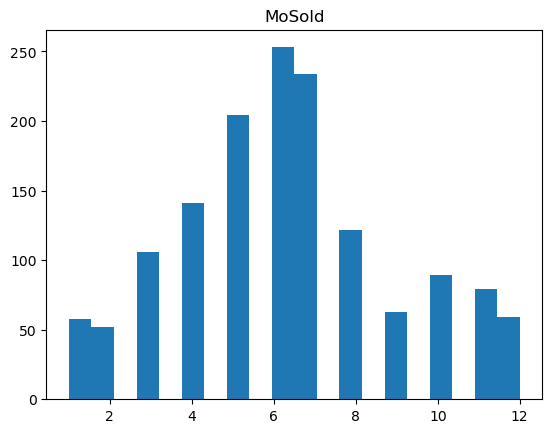

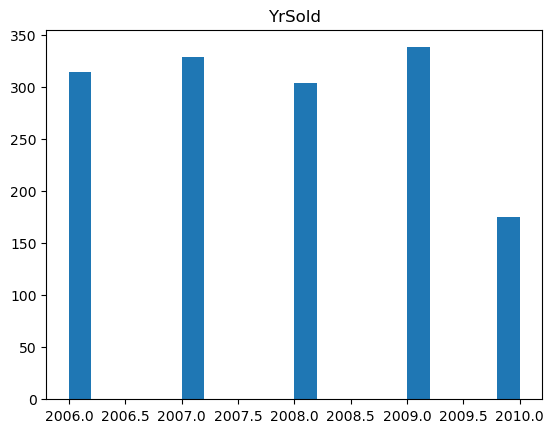

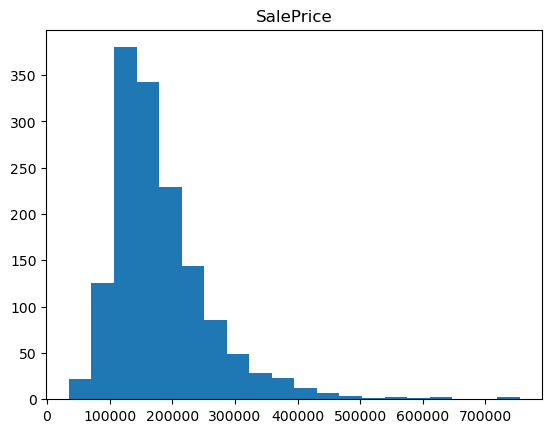

In [24]:
# III. Visualize features
for col in data.select_dtypes(include=["float64", "int64"]).columns:
    plt.hist(data[col].dropna(), bins=20)
    plt.title(col)
    plt.show()

In [25]:
# IV. Preprocess data
data = data.dropna()  # Drop missing values for simplicity
X = data.drop("SalePrice", axis=1)
y = data["SalePrice"]

In [28]:
if X.select_dtypes(include=["float64", "int64"]).shape[1] > 0:
    X = X.select_dtypes(include=["float64", "int64"])
else:
    print("No numeric features found.")
    raise ValueError("The dataset has no numeric features to train the model.")

if X.select_dtypes(include=["object", "category"]).shape[1] > 0:
    X = pd.get_dummies(X, drop_first=True)  # One-hot encode categorical features
    print("Categorical features were encoded.")

# Confirm the shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (8000, 784)
X_test shape: (2000, 784)
y_train shape: (8000,)
y_test shape: (2000,)


In [29]:

# V. Train models
regressors = {
    "Linear Regression": LinearRegression(),
    "SVM": SVR(),
    "Decision Tree": DecisionTreeClassifier()
}

In [30]:
# VI. Hyperparameter tuning
param_grids_reg = {
    "Linear Regression": {},
    "SVM": {"C": [0.1, 1, 10]},
    "Decision Tree": {"max_depth": [5, 10, 20]}
}


In [31]:

best_regressors = {}
for name, model in regressors.items():
    grid = GridSearchCV(model, param_grids_reg[name], cv=3, scoring="neg_mean_absolute_error")
    grid.fit(X_train, y_train)
    best_regressors[name] = grid.best_estimator_

In [32]:
# VII. Evaluate models
for name, model in best_regressors.items():
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    print(f"\n{name}")
    print(f"Train MAE: {mean_absolute_error(y_train, y_pred_train):.2f}")
    print(f"Test MAE: {mean_absolute_error(y_test, y_pred_test):.2f}")



Linear Regression
Train MAE: 1.36
Test MAE: 118450055.12

SVM
Train MAE: 0.14
Test MAE: 0.53

Decision Tree
Train MAE: 0.00
Test MAE: 0.60


In [33]:
# VIII. Evaluate training performance
for name, model in best_regressors.items():
    y_pred_train = model.predict(X_train)
    print(f"\n{name} Training Performance:")
    print(f"MAE: {mean_absolute_error(y_train, y_pred_train):.2f}")
    print(f"MSE: {mean_squared_error(y_train, y_pred_train):.2f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.2f}")


Linear Regression Training Performance:
MAE: 1.36
MSE: 2.97
RMSE: 1.72

SVM Training Performance:
MAE: 0.14
MSE: 0.10
RMSE: 0.31

Decision Tree Training Performance:
MAE: 0.00
MSE: 0.01
RMSE: 0.08


In [34]:
# IX. Evaluate test performance
for name, model in best_regressors.items():
    y_pred_test = model.predict(X_test)
    print(f"\n{name} Test Performance:")
    print(f"MAE: {mean_absolute_error(y_test, y_pred_test):.2f}")
    print(f"MSE: {mean_squared_error(y_test, y_pred_test):.2f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.2f}")


Linear Regression Test Performance:
MAE: 118450055.12
MSE: 8320507422969098240.00
RMSE: 2884528977.66

SVM Test Performance:
MAE: 0.53
MSE: 0.74
RMSE: 0.86

Decision Tree Test Performance:
MAE: 0.60
MSE: 2.83
RMSE: 1.68


In [35]:
# X. Compare models and select the best one
print("\nModel Comparison (Test Data):")
for name, model in best_regressors.items():
    y_pred_test = model.predict(X_test)
    print(f"{name}: RMSE={np.sqrt(mean_squared_error(y_test, y_pred_test)):.2f}")



Model Comparison (Test Data):
Linear Regression: RMSE=2884528977.66
SVM: RMSE=0.86
Decision Tree: RMSE=1.68


### Experiment 3 : Ensemble Methods

In [36]:
# I. Train Voting Classifier
from sklearn.ensemble import VotingClassifier

In [37]:
voting = VotingClassifier(estimators=list(best_models.items()))
voting.fit(X_train, y_train)
print("\nVoting Classifier Accuracy:", voting.score(X_test, y_test))


Voting Classifier Accuracy: 0.956


In [39]:
# II. Train Bagging Classifier
from sklearn.ensemble import BaggingClassifier

bagging = BaggingClassifier(estimator=LogisticRegression(max_iter=100), n_estimators=10)
bagging.fit(X_train, y_train)
print("\nBagging Classifier Accuracy:", bagging.score(X_test, y_test))

/Applications/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Applications/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-


Bagging Classifier Accuracy: 0.923


/Applications/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [40]:
# III. Train Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("\nRandom Forest Classifier Accuracy:", rf.score(X_test, y_test))


Random Forest Classifier Accuracy: 0.9595


In [41]:

# IV. Train Stacking Classifier
from sklearn.ensemble import StackingClassifier

stacking = StackingClassifier(estimators=list(best_models.items()), final_estimator=LogisticRegression())
stacking.fit(X_train, y_train)
print("\nStacking Classifier Accuracy:", stacking.score(X_test, y_test))

/Applications/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Stacking Classifier Accuracy: 0.966


In [42]:
# V. Train Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier

boosting = GradientBoostingClassifier()
boosting.fit(X_train, y_train)
print("\nBoosting Classifier Accuracy:", boosting.score(X_test, y_test))



Boosting Classifier Accuracy: 0.9355


### Experiment 4 : Clustering

#### I. K-Means Clustering for Digits

In [45]:
# Import necessary libraries
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [46]:
# Load the dataset of Experiment 1 (MNIST dataset)
digits_data = pd.read_csv("digit.csv") 

In [47]:
# Preprocess the data
X_digits = digits_data.iloc[:, 1:].values  # Exclude labels
X_digits = X_digits / 255.0  # Normalize pixel values


In [48]:
# Reduce the dataset for faster execution (optional)
from sklearn.utils import resample
X_digits = resample(X_digits, n_samples=5000, random_state=42)

In [49]:
# Scale the data
scaler = StandardScaler()
X_digits_scaled = scaler.fit_transform(X_digits)


In [50]:
# Apply K-Means Clustering
kmeans = KMeans(n_clusters=10, random_state=42)
digit_clusters = kmeans.fit_predict(X_digits_scaled)

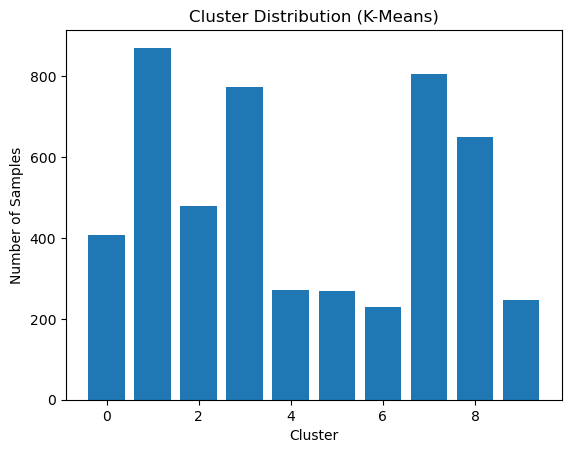


K-Means Clusters for Digits:
 {0: 407, 1: 870, 2: 480, 3: 772, 4: 272, 5: 268, 6: 230, 7: 804, 8: 650, 9: 247}


In [51]:
# Visualize the cluster distribution
unique, counts = np.unique(digit_clusters, return_counts=True)
plt.bar(unique, counts)
plt.title("Cluster Distribution (K-Means)")
plt.xlabel("Cluster")
plt.ylabel("Number of Samples")
plt.show()

print("\nK-Means Clusters for Digits:\n", dict(zip(unique, counts)))



#### II. Hierarchical Clustering for Houses

In [52]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

In [53]:
# Load the dataset of Experiment 2 (House Price dataset)
house_data = pd.read_csv("house.csv")

In [54]:
# Step 1: Handle missing values
# Drop columns with more than 40% missing values
threshold = 0.4 * house_data.shape[0]
house_data_cleaned = house_data.dropna(thresh=threshold, axis=1)

In [55]:
# Fill missing values for numeric columns with median
for col in house_data_cleaned.select_dtypes(include=["float64", "int64"]):
    house_data_cleaned[col].fillna(house_data_cleaned[col].median(), inplace=True)

# Step 2: Select relevant numeric features
numeric_features = house_data_cleaned.select_dtypes(include=["float64", "int64"]).drop(columns=["Id", "SalePrice"])

# Step 3: Scale the data
scaler = StandardScaler()
numeric_features_scaled = scaler.fit_transform(numeric_features)


/var/folders/b1/06nddx952f1g_2r63y2n569c0000gn/T/ipykernel_97014/252776092.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  house_data_cleaned[col].fillna(house_data_cleaned[col].median(), inplace=True)
/var/folders/b1/06nddx952f1g_2r63y2n569c0000gn/T/ipykernel_97014/252776092.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  house_data_c

In [56]:

# Step 4: Reduce dataset size
from sklearn.utils import resample
numeric_features_scaled = resample(numeric_features_scaled, n_samples=500, random_state=42)

# Step 5: Perform hierarchical clustering
linked = linkage(numeric_features_scaled, method="ward")

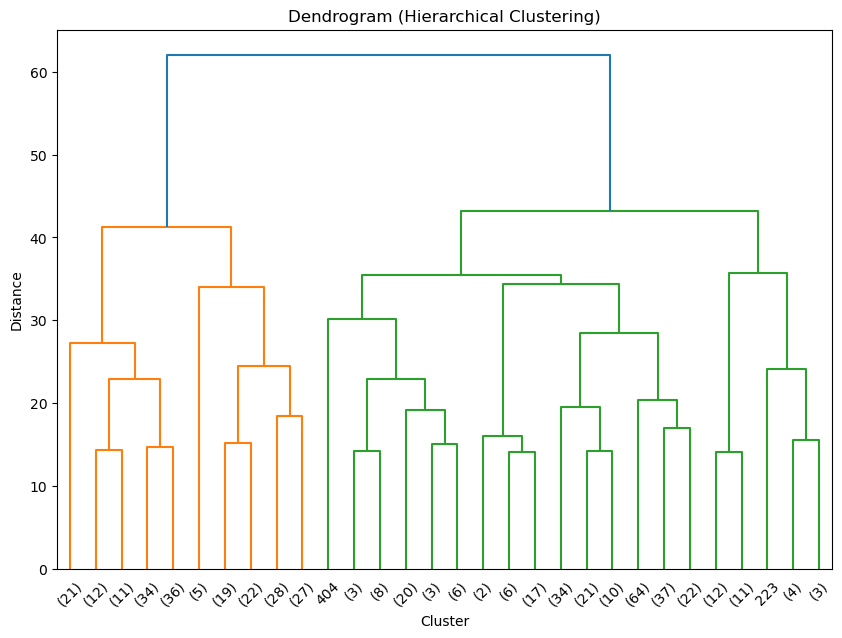

In [57]:
# Plot dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linked, truncate_mode="lastp", p=30, leaf_rotation=45, leaf_font_size=10)
plt.title("Dendrogram (Hierarchical Clustering)")
plt.xlabel("Cluster")
plt.ylabel("Distance")
plt.show()

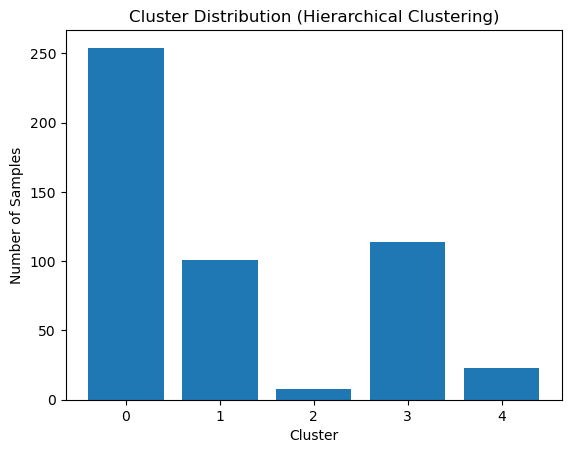


Hierarchical Clusters for Houses:
 {0: 254, 1: 101, 2: 8, 3: 114, 4: 23}


In [60]:
# Step 6: Apply Agglomerative Clustering
hc = AgglomerativeClustering(n_clusters=5, metric="euclidean", linkage="ward")
house_clusters = hc.fit_predict(numeric_features_scaled)

# Visualize the cluster distribution
import numpy as np
unique, counts = np.unique(house_clusters, return_counts=True)
plt.bar(unique, counts)
plt.title("Cluster Distribution (Hierarchical Clustering)")
plt.xlabel("Cluster")
plt.ylabel("Number of Samples")
plt.show()

print("\nHierarchical Clusters for Houses:\n", dict(zip(unique, counts)))
